# 10 — PSM Fase B3: propensity score matching

**Universo:** `panel_canavieiro_main` (842 munis × 10 anos), de onde extraímos snapshot baseline 1 linha/muni.

**Tratamento:** binário `is_treated_ever` (194 tratados ANP-CS, 648 controles canavieiros).

**Especificações (4):** LEAN(21) / FULL(35) / RICH(56) / FULL−2(33, robustez), conforme documento de especificações.

**Métodos (2):** logit padrão + LASSO com CV(5).

**Critérios de suporte comum (4):** Crump et al. (2009) [principal], trim absoluto 5/95, min-max overlap, Kennedy et al. (2022).

**Total:** 4 × 2 = 8 modelos × 4 critérios = 32 amostras analíticas + tabelas comparativas.

**Decisões metodológicas v2.3.3:**
- §3.7.1: `share_cana_baseline` (= `mb_share_cana_pre`) entra no IPW mas **não** no outcome regression.
- §3.7.1: `n_usinas_baseline` demovido (192/194 = 0); fica como sensibilidade, fora das 3 specs principais.
- §3.5.3: tratamento binário `is_treated_ever`; coorte `g_m` é registrada para uso posterior em CS staggered (não usado neste notebook).

**Outputs em `data/interim/`:**
- `psm_pscores.csv` — 1 linha/muni × 6 colunas pscore (3 specs × 2 métodos)
- `psm_weights_ipw.csv` — IPW weights por muni para cada modelo
- `psm_support_masks.csv` — máscaras booleanas (in/out support) para cada modelo × critério
- `psm_diagnostics.csv` — AUC, pseudo-R², SMDs, n_in_support por modelo

**Tempo esperado:** ~2-3 minutos.

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
from pathlib import Path
BASE_DIR = Path('/content/drive/MyDrive/Renovabio - EcoEco')
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from pipeline.config import interim, out_pre
print('✓ setup OK')

Mounted at /content/drive
✓ setup OK


## Bloco 1 — Construir snapshot baseline cross-section

Filtra `panel_canavieiro_main` para janela baseline 2015–2019 e agrega 1 linha/muni.

**Estratégia de agregação:** mean para variáveis contínuas (intensidades, shares, indicadores socioeconômicos), max para áreas absolutas (escala canavieira via PAM e MapBiomas).

**Mas para PSM precisamos da BASE BRUTA** (`base_psm_integrada_raw.csv`) com nomes `0_*`, `1_*`, etc., porque o `build_covariates_raw()` opera nesses nomes. O painel canavieiro tem nomes canônicos e covariáveis derivadas incompletas.

Estratégia:
1. Carregar `base_psm_integrada_raw.csv` (5.570 munis × 165 cols, ano único = 2017)
2. Carregar `panel_canavieiro_main.csv` para extrair `geocode + is_treated_ever + g_m` (1 linha/muni)
3. Inner join via `geocode` → 842 munis com covs raw + tratamento

In [2]:
# Carregar painel canavieiro (8420 cells × 139) e extrair muni-level
panel = pd.read_csv(
    BASE_DIR / 'data/interim/panel_canavieiro_main.csv',
    dtype={'geocode': str},
)
print(f'panel_canavieiro_main: {panel.shape}')

# 1 linha por muni — extrai is_treated_ever, g_m, e identificadores
muni_treat = (panel
    .groupby('geocode', as_index=False)
    .agg(
        municipio=('municipio', 'first'),
        uf=('uf', 'first'),
        is_treated_ever=('is_treated_ever', 'first'),
        g_m=('g_m', 'first'),
        bioma=('bioma', 'first'),
    ))
muni_treat['treated'] = muni_treat['is_treated_ever'].astype(int)

print(f'\nMunis canavieiros: {len(muni_treat)} (esperado 842)')
print(f'Tratados: {muni_treat["treated"].sum()} (esperado 194)')
print(f'Controles: {(1 - muni_treat["treated"]).sum()} (esperado 648)')

panel_canavieiro_main: (8420, 139)

Munis canavieiros: 842 (esperado 842)
Tratados: 194 (esperado 194)
Controles: 648 (esperado 648)


In [3]:
# Carregar base PSM raw — Brasil inteiro
psm_raw = pd.read_csv(
    BASE_DIR / 'data/raw/psm_baseline/base_psm_integrada_raw.csv',
    low_memory=False,
)
psm_raw['geocode'] = psm_raw['0_cd_ibge'].astype(str).str.zfill(7)
print(f'base_psm_integrada_raw: {psm_raw.shape}')

# Bioma com fix de mojibake (consistência com pipeline.psm_baseline)
BIOMA_FIXES = {
    'Amaz\ufffd\ufffdnia': 'Amazônia',
    'Mata Atl\ufffd\ufffdntica': 'Mata Atlântica',
}
if '14_bioma' in psm_raw.columns:
    psm_raw['14_bioma'] = psm_raw['14_bioma'].replace(BIOMA_FIXES)

# Inner join: 842 canavieiros com covs raw
df_raw_cs = muni_treat.merge(psm_raw, on='geocode', how='inner')
print(f'\nApós inner join: {df_raw_cs.shape}')
print(f'Esperado: 842 munis')

if len(df_raw_cs) != 842:
    perdidos = set(muni_treat['geocode']) - set(psm_raw['geocode'])
    print(f'⚠️  Munis canavieiros sem registro PSM: {len(perdidos)}')
    print(f'    Lista: {sorted(perdidos)[:10]}...')

base_psm_integrada_raw: (5570, 166)

Após inner join: (842, 172)
Esperado: 842 munis


## Bloco 2 — Aplicar `build_covariates_raw` (fonte: documento de especificações)

Reproduz a função do TCC original com adaptações v2.3.3:
- `mb_share_cana` → renomeado como `share_cana_baseline` (vocabulário §3.7.1)
- Demais nomes preservados para retrocompatibilidade com diagnóstico do Passo 5

In [4]:
# Funções utilitárias
def safe_log1p(s, idx):
    s = pd.to_numeric(s, errors='coerce') if s is not None else pd.Series(np.nan, index=idx)
    return np.log1p(s.clip(lower=0))

def safe_div(num, den, idx):
    num = pd.to_numeric(num, errors='coerce') if num is not None else pd.Series(np.nan, index=idx)
    den = pd.to_numeric(den, errors='coerce') if den is not None else pd.Series(np.nan, index=idx)
    return np.where((den.notna()) & (den > 0), num / den, np.nan)

def as_numeric_series(s, idx):
    return pd.to_numeric(s, errors='coerce') if s is not None else pd.Series(np.nan, index=idx)


def build_covariates_raw(df: pd.DataFrame) -> pd.DataFrame:
    """Constrói covariáveis derivadas a partir dos nomes raw `0_*`, `1_*`, etc.

    Adaptação v2.3.3:
    - `mb_share_cana` foi renomeado para `share_cana_baseline` (vocabulário §3.7.1)
    """
    d = df.copy()
    idx = d.index

    # ----- Porte / escala -----
    d['log_pib_total']  = safe_log1p(d.get('1_pib_total'), idx)
    d['log_pib_pc']     = safe_log1p(d.get('1_pib_percap'), idx)
    d['log_pop']        = safe_log1p(d.get('2_pop_2017_ibge'), idx)
    d['log_area_total'] = safe_log1p(d.get('14_area_total'), idx)
    d['densidade_pop']  = safe_div(d.get('2_pop_2017_ibge'), d.get('14_area_total'), idx)

    # ----- Estrutura setorial (VADC) -----
    d['share_vadc_agro'] = safe_div(d.get('1_vadc_agro'), d.get('1_vadc_bruto'), idx)
    d['share_vadc_ind']  = safe_div(d.get('1_vadc_ind'),  d.get('1_vadc_bruto'), idx)
    d['share_vadc_serv'] = safe_div(d.get('1_vadc_serv'), d.get('1_vadc_bruto'), idx)
    d['share_vadc_adm']  = safe_div(d.get('1_vadc_adm'),  d.get('1_vadc_bruto'), idx)

    # ----- Uso do solo MapBiomas pré-2020 -----
    # ADAPTAÇÃO v2.3.3: mb_share_cana → share_cana_baseline (vocabulário §3.7.1)
    d['share_cana_baseline']        = as_numeric_series(d.get('3_mb_sharegrp_pre_cana'), idx)
    d['mb_share_soja']              = as_numeric_series(d.get('3_mb_sharegrp_pre_soja'), idx)
    d['mb_share_pastagem']          = as_numeric_series(d.get('3_mb_sharegrp_pre_pastagem'), idx)
    d['mb_share_vegetacao_nativa']  = as_numeric_series(d.get('3_mb_sharegrp_pre_vegetacao_nativa'), idx)
    d['mb_share_urbano']            = as_numeric_series(d.get('3_mb_sharegrp_pre_urbano_infra'), idx)

    # ----- Agricultura (PAM) -----
    d['log_area_cana']        = safe_log1p(d.get('4_area_colhida_ha_cana'), idx)
    d['log_area_soja']        = safe_log1p(d.get('4_area_colhida_ha_soja'), idx)
    d['log_area_agri_total']  = safe_log1p(d.get('4_area_colhida_ha'), idx)
    d['share_area_cana_agri'] = safe_div(d.get('4_area_colhida_ha_cana'), d.get('4_area_colhida_ha'), idx)

    # ----- Estrutura agrária (Censo Agro) -----
    d['share_est_af']  = safe_div(d.get('5_num_est_af'),  d.get('5_num_est_total'), idx)
    d['share_est_mp']  = safe_div(d.get('5_num_est_mp'),  d.get('5_num_est_total'), idx)
    d['share_area_af'] = safe_div(d.get('6_area_lav_af'), d.get('6_area_lav_total'), idx)
    d['share_area_mp'] = safe_div(d.get('6_area_lav_mp'), d.get('6_area_lav_total'), idx)

    # ----- Tecnologia / irrigação / financiamento / AT -----
    d['trator_per_est']      = safe_div(d.get('11_num_trator_total'), d.get('5_num_est_total'), idx)
    d['share_est_irrig']     = safe_div(d.get('12_num_est_irrig_total'), d.get('5_num_est_total'), idx)
    d['share_area_irrig']    = safe_div(d.get('12_area_irrig_total'), d.get('6_area_lav_total'), idx)
    d['share_est_fin_total'] = safe_div(d.get('13_num_est_fin_total'), d.get('5_num_est_total'), idx)
    d['share_est_at']        = safe_div(d.get('10_num_est_receb_at'), d.get('5_num_est_total'), idx)

    # ----- Ambiente -----
    d['natveg_share_area'] = safe_div(d.get('14_vegetacao_natural'), d.get('14_area_total'), idx)
    d['desmat_share_area'] = safe_div(d.get('14_desmatado'), d.get('14_area_total'), idx)

    # ----- Socioeconômico -----
    d['idhm_renda'] = as_numeric_series(d.get('17_idhm_renda'), idx)
    d['idhm_educ']  = as_numeric_series(d.get('17_idhm_educ'), idx)
    d['ivs_infra']  = as_numeric_series(d.get('17_ivs_infraestrutura_urbana'), idx)
    d['gini']       = as_numeric_series(d.get('17_i_gini'), idx)

    # ----- FULL extras -----
    d['idhm_long']           = as_numeric_series(d.get('17_idhm_long'), idx)
    d['ivs_capital_humano']  = as_numeric_series(d.get('17_ivs_capital_humano'), idx)
    d['ivs_renda_trabalho']  = as_numeric_series(d.get('17_ivs_renda_e_trabalho'), idx)
    d['share_est_at_coop']   = safe_div(d.get('10_num_est_receb_at_coop'), d.get('5_num_est_total'), idx)
    d['share_est_at_gov']    = safe_div(d.get('10_num_est_receb_at_gov'),  d.get('5_num_est_total'), idx)
    d['share_fin_invest']    = safe_div(d.get('13_num_est_fin_invest'),    d.get('5_num_est_total'), idx)
    d['share_fin_cust']      = safe_div(d.get('13_num_est_fin_cust'),      d.get('5_num_est_total'), idx)
    d['share_est_trator']    = safe_div(d.get('11_num_est_trator_total'),  d.get('5_num_est_total'), idx)
    d['share_est_irrig_pivo'] = safe_div(d.get('12_num_est_irrig_pivo'),   d.get('5_num_est_total'), idx)
    d['pct_est_energia']     = as_numeric_series(d.get('7_est_com_energia%'), idx)

    # ----- RICH extras -----
    d['log_area_milho']      = safe_log1p(d.get('4_area_colhida_ha_milho'), idx)
    d['log_area_alg']        = safe_log1p(d.get('4_area_colhida_ha_alg'), idx)
    d['log_area_cafarab']    = safe_log1p(d.get('4_area_colhida_ha_cafarab'), idx)
    d['log_area_cafcan']     = safe_log1p(d.get('4_area_colhida_ha_cafcan'), idx)
    d['mb_share_cafe']       = as_numeric_series(d.get('3_mb_sharegrp_pre_cafe'), idx)
    d['mb_share_algodao']    = as_numeric_series(d.get('3_mb_sharegrp_pre_algodao'), idx)
    d['mb_share_silvicultura'] = as_numeric_series(d.get('3_mb_sharegrp_pre_silvicultura'), idx)
    d['mb_share_agua']       = as_numeric_series(d.get('3_mb_sharegrp_pre_agua'), idx)
    d['mb_share_outros']     = as_numeric_series(d.get('3_mb_sharegrp_pre_outros'), idx)
    d['mb_share_agri_total'] = as_numeric_series(d.get('3_mb_sharegrp_pre_agricultura_total'), idx)
    d['share_num_est_mp']    = safe_div(d.get('5_num_est_mp'),  d.get('5_num_est_total'), idx)
    d['share_est_pec']       = safe_div(d.get('5_num_est_pec_total'),    d.get('5_num_est_total'), idx)
    d['share_est_lavperm']   = safe_div(d.get('5_num_est_lavperm_total'), d.get('5_num_est_total'), idx)
    d['share_est_lavtemp']   = safe_div(d.get('5_num_est_lavtemp_total'), d.get('5_num_est_total'), idx)
    d['share_area_lavperm']  = safe_div(d.get('6_area_lavperm_total'), d.get('6_area_lav_total'), idx)
    d['share_area_lavtemp']  = safe_div(d.get('6_area_lavtemp_total'), d.get('6_area_lav_total'), idx)
    d['share_area_pec']      = safe_div(d.get('6_area_pec_total'),     d.get('6_area_lav_total'), idx)
    d['share_fin_comer']     = safe_div(d.get('13_num_est_fin_comer'),    d.get('5_num_est_total'), idx)
    d['share_est_at_propr']  = safe_div(d.get('10_num_est_receb_at_propr'),   d.get('5_num_est_total'), idx)
    d['share_est_at_gov_out'] = safe_div(d.get('10_num_est_receb_at_gov_out'), d.get('5_num_est_total'), idx)

    # ----- Clip de shares (heurística do TCC) -----
    share_cols = [c for c in d.columns if ('share' in c) or c.startswith('mb_share_')]
    for c in share_cols:
        s = pd.to_numeric(d[c], errors='coerce')
        if not s.dropna().empty and (s.dropna().between(-0.05, 1.05).mean() > 0.8):
            d[c] = s.clip(0, 1)
        else:
            d[c] = s

    return d


df_psm = build_covariates_raw(df_raw_cs)
print(f'df_psm shape: {df_psm.shape}')
print(f'Tratados: {df_psm["treated"].sum()}')

df_psm shape: (842, 235)
Tratados: 194


## Bloco 3 — Definir LEAN(21) / FULL(35) / RICH(56) / FULL−2(33)

Listas exatas do documento de especificações + FULL−2 adicionada empiricamente para resolver structural overlap em `share_vadc_agro/ind` (§3.7.4 v2.3.4), com **adaptação v2.3.3**: `mb_share_cana` → `share_cana_baseline`.

In [5]:
COVS_LEAN = [
    # Estrutura econômica e demográfica (7)
    'log_pib_total', 'log_pib_pc', 'log_pop', 'densidade_pop',
    'share_vadc_agro', 'share_vadc_ind', 'share_vadc_serv',
    # Uso do solo MapBiomas pré (4) — share_cana_baseline = mb_share_cana
    'share_cana_baseline', 'mb_share_soja', 'mb_share_pastagem', 'mb_share_vegetacao_nativa',
    # Escala canavieira PAM (3)
    'log_area_cana', 'log_area_soja', 'share_area_cana_agri',
    # Estrutura agrária (2)
    'share_est_af', 'share_area_af',
    # Tecnologia/crédito (3)
    'trator_per_est', 'share_est_irrig', 'share_est_fin_total',
    # Socioeconômico (2)
    'ivs_infra', 'gini',
]
assert len(COVS_LEAN) == 21, f'LEAN tem {len(COVS_LEAN)} covs (esperado 21)'

COVS_FULL = COVS_LEAN + [
    # Setorial refinada (1)
    'share_vadc_adm',
    # Sub-índices IDHM e IVS (5)
    'idhm_educ', 'idhm_renda', 'idhm_long', 'ivs_capital_humano', 'ivs_renda_trabalho',
    # AT por fonte (3)
    'share_est_at', 'share_est_at_coop', 'share_est_at_gov',
    # Crédito por finalidade (2)
    'share_fin_invest', 'share_fin_cust',
    # Mecanização refinada (2)
    'share_est_trator', 'share_est_irrig_pivo',
    # Eletrificação (1)
    'pct_est_energia',
]
assert len(COVS_FULL) == 35, f'FULL tem {len(COVS_FULL)} covs (esperado 35)'

COVS_RICH = COVS_FULL + [
    # Diversificação por culturas (4)
    'log_area_milho', 'log_area_alg', 'log_area_cafarab', 'log_area_cafcan',
    # Diversificação MapBiomas (7)
    'mb_share_cafe', 'mb_share_algodao', 'mb_share_silvicultura',
    'mb_share_urbano', 'mb_share_agua', 'mb_share_outros', 'mb_share_agri_total',
    # Estrutura agrária detalhada (7)
    'share_num_est_mp', 'share_est_pec', 'share_est_lavperm', 'share_est_lavtemp',
    'share_area_lavperm', 'share_area_lavtemp', 'share_area_pec',
    # Crédito e AT detalhados (3)
    'share_fin_comer', 'share_est_at_propr', 'share_est_at_gov_out',
]
assert len(COVS_RICH) == 56, f'RICH tem {len(COVS_RICH)} covs (esperado 56)'

# Verifica que LEAN ⊂ FULL ⊂ RICH (hierarquia confirmada)
assert set(COVS_LEAN).issubset(set(COVS_FULL)), 'LEAN não está contido em FULL'
assert set(COVS_FULL).issubset(set(COVS_RICH)), 'FULL não está contido em RICH'

# FULL-2: FULL menos `share_vadc_agro` e `share_vadc_ind` (robustez ad hoc, justificativa em §3.7.4 v2.3.4)
# Motivação empírica: estas duas covariáveis apresentam |SMD| > 0.25 pós-PSM sob FULL_std,
# refletindo *structural overlap violation* — usinas ANP elevam mecanicamente o peso industrial
# (e reduzem agro relativo) do município tratado, gerando diferença irredutível por matching.
# A remoção é coerente com a política de bad-control declarada em §3.7.1 v2.3.3 para `share_cana_baseline`:
# variáveis correlacionadas com o mecanismo causal são tratadas com cautela.
COVS_FULL2 = [c for c in COVS_FULL if c not in ('share_vadc_agro', 'share_vadc_ind')]
assert len(COVS_FULL2) == 33, f'FULL-2 tem {len(COVS_FULL2)} covs (esperado 33)'

SPECS = {'LEAN': COVS_LEAN, 'FULL': COVS_FULL, 'FULL2': COVS_FULL2, 'RICH': COVS_RICH}
print(f'✓ LEAN:  {len(COVS_LEAN)} covs')
print(f'✓ FULL:  {len(COVS_FULL)} covs')
print(f'✓ FULL-2: {len(COVS_FULL2)} covs (sem share_vadc_agro/ind)')
print(f'✓ RICH: {len(COVS_RICH)} covs')
print(f'✓ Hierarquia LEAN ⊂ FULL ⊂ RICH confirmada')

# Verifica que todas as covs existem em df_psm
for spec_name, covs in SPECS.items():
    missing = [c for c in covs if c not in df_psm.columns]
    if missing:
        print(f'⚠️  {spec_name} — faltam: {missing}')
    else:
        print(f'✓ {spec_name}: todas as {len(covs)} covs presentes em df_psm')

✓ LEAN:  21 covs
✓ FULL:  35 covs
✓ FULL-2: 33 covs (sem share_vadc_agro/ind)
✓ RICH: 56 covs
✓ Hierarquia LEAN ⊂ FULL ⊂ RICH confirmada
✓ LEAN: todas as 21 covs presentes em df_psm
✓ FULL: todas as 35 covs presentes em df_psm
✓ FULL2: todas as 33 covs presentes em df_psm
✓ RICH: todas as 56 covs presentes em df_psm


## Bloco 4 — Imputação por mediana estadual e pré-processamento

Conforme documento de especificações (Passo 6): mediana estadual para variáveis com cobertura ≥90%; StandardScaler antes do logit.

In [6]:
all_covs = sorted(set(COVS_RICH))  # superset

# Diagnóstico de cobertura
cov_report = []
for c in all_covs:
    n_obs = df_psm[c].notna().sum()
    cov_report.append({
        'covariavel': c,
        'n_obs': n_obs,
        'pct_cob': 100 * n_obs / len(df_psm),
    })
cov_report = pd.DataFrame(cov_report).sort_values('pct_cob')

low_cov = cov_report.query('pct_cob < 90')
if len(low_cov) > 0:
    print(f'⚠️  {len(low_cov)} covs com cobertura < 90%:')
    print(low_cov.to_string(index=False))
else:
    print('✓ Todas as covs com cobertura ≥ 90%')

✓ Todas as covs com cobertura ≥ 90%


In [7]:
# Imputação por mediana ESTADUAL (UF do muni)
for c in all_covs:
    if df_psm[c].isna().any():
        # Mediana por UF
        df_psm[c] = df_psm.groupby('uf')[c].transform(
            lambda x: x.fillna(x.median())
        )
        # Fallback global se UF inteira NaN
        df_psm[c] = df_psm[c].fillna(df_psm[c].median())

n_nan_after = df_psm[all_covs].isna().sum().sum()
print(f'NaN restantes após imputação: {n_nan_after}')
assert n_nan_after == 0, 'Ainda há NaN após imputação'

NaN restantes após imputação: 0


## Bloco 5 — Estimar 6 modelos (3 specs × {logit padrão, LASSO})

**`share_cana_baseline` é incluído em todas as specs (entra no logit/IPW conforme §3.7.1).**
Mais tarde, no estágio de DiD, ela é excluída do outcome regression — isso é controlado pelo notebook de modelagem causal, não aqui.

In [8]:
y = df_psm['treated'].values
results = {}  # {model_key: {'pscore', 'auc', 'pseudo_r2', 'n_active', 'active_covs'}}

for spec_name, covs in SPECS.items():
    X_raw = df_psm[covs].values
    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    # ----- Logit padrão -----
    model_std = LogisticRegression(
        penalty=None, solver='lbfgs', max_iter=2000, random_state=42
    )
    model_std.fit(X, y)
    pscore_std = model_std.predict_proba(X)[:, 1]
    auc_std = roc_auc_score(y, pscore_std)

    # McFadden pseudo-R²
    from sklearn.metrics import log_loss
    p_null = y.mean()
    ll_null = log_loss(y, np.full_like(y, p_null, dtype=float), normalize=False)
    ll_full = log_loss(y, pscore_std, normalize=False)
    pseudo_r2_std = 1 - ll_full / ll_null

    n_active_std = (np.abs(model_std.coef_[0]) > 1e-6).sum()
    active_covs_std = [c for c, b in zip(covs, model_std.coef_[0]) if abs(b) > 1e-6]

    results[f'{spec_name}_std'] = {
        'pscore': pscore_std,
        'auc': auc_std,
        'pseudo_r2': pseudo_r2_std,
        'n_active': n_active_std,
        'active_covs': active_covs_std,
        'covs': covs,
    }

    # ----- LASSO com CV(5) -----
    model_lasso = LogisticRegressionCV(
        Cs=10, cv=5, penalty='l1', solver='saga',
        max_iter=5000, scoring='neg_log_loss', random_state=42, n_jobs=-1,
    )
    model_lasso.fit(X, y)
    pscore_lasso = model_lasso.predict_proba(X)[:, 1]
    auc_lasso = roc_auc_score(y, pscore_lasso)

    ll_lasso = log_loss(y, pscore_lasso, normalize=False)
    pseudo_r2_lasso = 1 - ll_lasso / ll_null

    n_active_lasso = (np.abs(model_lasso.coef_[0]) > 1e-6).sum()
    active_covs_lasso = [c for c, b in zip(covs, model_lasso.coef_[0]) if abs(b) > 1e-6]

    results[f'{spec_name}_lasso'] = {
        'pscore': pscore_lasso,
        'auc': auc_lasso,
        'pseudo_r2': pseudo_r2_lasso,
        'n_active': n_active_lasso,
        'active_covs': active_covs_lasso,
        'covs': covs,
    }

    print(f'\n{spec_name}:')
    print(f'  std   AUC={auc_std:.4f} pseudo_R²={pseudo_r2_std:.3f} n_active={n_active_std}/{len(covs)}')
    print(f'  lasso AUC={auc_lasso:.4f} pseudo_R²={pseudo_r2_lasso:.3f} n_active={n_active_lasso}/{len(covs)}')

print('\n✓ 6 modelos estimados')


LEAN:
  std   AUC=0.8860 pseudo_R²=0.349 n_active=21/21
  lasso AUC=0.8828 pseudo_R²=0.341 n_active=16/21

FULL:
  std   AUC=0.8962 pseudo_R²=0.385 n_active=35/35
  lasso AUC=0.8928 pseudo_R²=0.374 n_active=21/35

FULL2:
  std   AUC=0.8758 pseudo_R²=0.342 n_active=33/33
  lasso AUC=0.8738 pseudo_R²=0.335 n_active=22/33

RICH:
  std   AUC=0.9038 pseudo_R²=0.408 n_active=56/56
  lasso AUC=0.8970 pseudo_R²=0.386 n_active=35/56

✓ 6 modelos estimados


## Bloco 6 — Comparar com diagnóstico TCC (Passo 5)

**Pergunta crítica:** AUC sob universo canavieiro v2.3 (842 munis, controles canavieiros) vs sob universo TCC (1.511 munis CS amplos).

**Predição:** AUC vai cair, porque discriminar tratado vs canavieiro-não-tratado é mais difícil do que tratado vs muni-CS-qualquer.

In [9]:
# Tabela comparativa
tcc_baseline = {
    'LEAN_std':   {'auc': 0.9727, 'pseudo_r2': 0.587, 'n_active': 21},
    'LEAN_lasso': {'auc': None,   'pseudo_r2': None,  'n_active': 4},
    'FULL_std':   {'auc': 0.9750, 'pseudo_r2': 0.607, 'n_active': 35},
    'FULL_lasso': {'auc': None,   'pseudo_r2': None,  'n_active': 5},
    'RICH_std':   {'auc': 0.9775, 'pseudo_r2': 0.628, 'n_active': 56},
    'RICH_lasso': {'auc': None,   'pseudo_r2': None,  'n_active': 8},
}

compare = []
for k, r in results.items():
    tcc = tcc_baseline.get(k, {})
    compare.append({
        'model': k,
        'AUC_v23': round(r['auc'], 4),
        'AUC_TCC': tcc.get('auc'),
        'ΔAUC': round(r['auc'] - tcc['auc'], 4) if tcc.get('auc') else None,
        'pseudoR2_v23': round(r['pseudo_r2'], 3),
        'pseudoR2_TCC': tcc.get('pseudo_r2'),
        'n_active_v23': r['n_active'],
        'n_active_TCC': tcc.get('n_active'),
    })
compare = pd.DataFrame(compare)
print('Comparação v2.3 (canavieiros 842) × TCC (CS 1.511):\n')
print(compare.to_string(index=False))
print('\nInterpretação esperada: AUC v2.3 < AUC TCC (universo restrito = controles mais similares).')

Comparação v2.3 (canavieiros 842) × TCC (CS 1.511):

      model  AUC_v23  AUC_TCC    ΔAUC  pseudoR2_v23  pseudoR2_TCC  n_active_v23  n_active_TCC
   LEAN_std   0.8860   0.9727 -0.0867         0.349         0.587            21          21.0
 LEAN_lasso   0.8828      NaN     NaN         0.341           NaN            16           4.0
   FULL_std   0.8962   0.9750 -0.0788         0.385         0.607            35          35.0
 FULL_lasso   0.8928      NaN     NaN         0.374           NaN            21           5.0
  FULL2_std   0.8758      NaN     NaN         0.342           NaN            33           NaN
FULL2_lasso   0.8738      NaN     NaN         0.335           NaN            22           NaN
   RICH_std   0.9038   0.9775 -0.0737         0.408         0.628            56          56.0
 RICH_lasso   0.8970      NaN     NaN         0.386           NaN            35           8.0

Interpretação esperada: AUC v2.3 < AUC TCC (universo restrito = controles mais similares).


## Bloco 7 — Estimar suporte comum × 4 critérios

Para cada modelo (6 total), aplica 4 critérios e reporta perda.

In [10]:
def support_crump(p, treated, alpha=0.025):
    """Crump et al. (2009): drop tratados < q(alpha, controles), controles > q(1-alpha, tratados)."""
    p_treat = p[treated == 1]
    p_ctrl = p[treated == 0]
    lo = np.quantile(p_ctrl, alpha)
    hi = np.quantile(p_treat, 1 - alpha)
    return (p >= lo) & (p <= hi), (lo, hi)

def support_trim(p, lo=0.05, hi=0.95):
    """Trim absoluto."""
    return (p >= lo) & (p <= hi), (lo, hi)

def support_minmax(p, treated):
    """Min-max overlap (interseção das distribuições)."""
    p_treat = p[treated == 1]
    p_ctrl = p[treated == 0]
    lo = max(p_treat.min(), p_ctrl.min())
    hi = min(p_treat.max(), p_ctrl.max())
    return (p >= lo) & (p <= hi), (lo, hi)

def support_kennedy(p, treated):
    """Kennedy et al. (2022): Crump generalizado com critério de variância.
    Aproximação simples: drop bottom 1% e top 1% do pscore (mais agressivo que Crump 2.5%)."""
    lo = np.quantile(p, 0.01)
    hi = np.quantile(p, 0.99)
    return (p >= lo) & (p <= hi), (lo, hi)

support_methods = {
    'crump_2.5': support_crump,
    'trim_5_95': support_trim,
    'minmax':    support_minmax,
    'kennedy_1': support_kennedy,
}

# Aplica todos os 4 critérios em cada modelo
support_table = []
support_masks = {}  # {(model, method): boolean array}

for model_key, r in results.items():
    p = r['pscore']
    for method_name, method_fn in support_methods.items():
        # Pass 'treated' (y) only to methods that require it
        if method_name == 'trim_5_95':
            mask, (lo, hi) = method_fn(p)
        else: # crump_2.5, minmax, kennedy_1 all require 'treated'
            mask, (lo, hi) = method_fn(p, y)
        n_treat_in = (mask & (y == 1)).sum()
        n_ctrl_in  = (mask & (y == 0)).sum()
        support_table.append({
            'model': model_key,
            'method': method_name,
            'lo': round(lo, 4),
            'hi': round(hi, 4),
            'n_in': mask.sum(),
            'n_treat_in': n_treat_in,
            'n_ctrl_in': n_ctrl_in,
            'pct_treat_in': round(100 * n_treat_in / 194, 1),
            'pct_ctrl_in':  round(100 * n_ctrl_in / 648, 1),
        })
        support_masks[(model_key, method_name)] = mask

support_df = pd.DataFrame(support_table)
print('Tabela de suporte comum (6 modelos × 4 critérios = 24 amostras):\n')
print(support_df.to_string(index=False))

Tabela de suporte comum (6 modelos × 4 critérios = 24 amostras):

      model    method     lo     hi  n_in  n_treat_in  n_ctrl_in  pct_treat_in  pct_ctrl_in
   LEAN_std crump_2.5 0.0000 0.9527   820         189        631          97.4         97.4
   LEAN_std trim_5_95 0.0500 0.9500   537         185        352          95.4         54.3
   LEAN_std    minmax 0.0089 0.9056   717         185        532          95.4         82.1
   LEAN_std kennedy_1 0.0000 0.9073   824         185        639          95.4         98.6
 LEAN_lasso crump_2.5 0.0001 0.9091   820         189        631          97.4         97.4
 LEAN_lasso trim_5_95 0.0500 0.9500   580         187        393          96.4         60.6
 LEAN_lasso    minmax 0.0083 0.8869   763         188        575          96.9         88.7
 LEAN_lasso kennedy_1 0.0000 0.8712   824         186        638          95.9         98.5
   FULL_std crump_2.5 0.0000 0.9577   820         189        631          97.4         97.4
   FULL_std tr

## Bloco 8 — Pesos IPW

Para uso posterior em CS doubly-robust e em TWFE pós-PSM.

In [11]:
weights_data = {'geocode': df_psm['geocode'].values, 'treated': y}
for model_key, r in results.items():
    p = r['pscore']
    # IPW: w = T/p + (1-T)/(1-p)
    w_ipw = np.where(y == 1, 1/p, 1/(1-p))
    # ATT-IPW: w_T = 1, w_C = p/(1-p)
    w_att = np.where(y == 1, 1.0, p/(1-p))
    weights_data[f'pscore_{model_key}'] = p
    weights_data[f'wipw_{model_key}'] = w_ipw
    weights_data[f'watt_{model_key}'] = w_att

weights_df = pd.DataFrame(weights_data)
print(f'Weights table: {weights_df.shape}')
print(f'Cols: {list(weights_df.columns)[:5]}...')

Weights table: (842, 26)
Cols: ['geocode', 'treated', 'pscore_LEAN_std', 'wipw_LEAN_std', 'watt_LEAN_std']...


## Bloco 9 — Balanço pré/pós (SMD) e Love plot — modelo principal FULL_std

In [12]:
def smd(x_t, x_c, w_t=None, w_c=None):
    """Standardized Mean Difference."""
    if w_t is None:
        m_t, v_t = x_t.mean(), x_t.var()
        m_c, v_c = x_c.mean(), x_c.var()
    else:
        m_t = np.average(x_t, weights=w_t)
        m_c = np.average(x_c, weights=w_c)
        v_t = np.average((x_t - m_t)**2, weights=w_t)
        v_c = np.average((x_c - m_c)**2, weights=w_c)
    pooled_sd = np.sqrt((v_t + v_c) / 2)
    if pooled_sd == 0:
        return 0
    return (m_t - m_c) / pooled_sd

# Modelo principal: FULL_std + Crump support
principal_key = 'FULL_std'
principal_method = 'crump_2.5'
support_mask = support_masks[(principal_key, principal_method)]

p = results[principal_key]['pscore']
w_att = np.where(y == 1, 1.0, p/(1-p))

# SMDs antes vs depois (no suporte) com pesos ATT-IPW
smd_before, smd_after = [], []
for c in COVS_FULL:
    x = df_psm[c].values
    # antes (toda amostra)
    smd_before.append(smd(x[y==1], x[y==0]))
    # depois (suporte + pesos ATT)
    s = support_mask
    smd_after.append(smd(
        x[s & (y==1)], x[s & (y==0)],
        w_t=w_att[s & (y==1)], w_c=w_att[s & (y==0)],
    ))

balance_df = pd.DataFrame({
    'covariavel': COVS_FULL,
    'SMD_pre': smd_before,
    'SMD_post': smd_after,
    '|SMD_pre|': np.abs(smd_before),
    '|SMD_post|': np.abs(smd_after),
}).sort_values('|SMD_pre|', ascending=False)

print(f'Balanço para {principal_key} + {principal_method} (n_in={support_mask.sum()}):\n')
print(balance_df.to_string(index=False))
print(f'\nSMD threshold convencional: |SMD| < 0.10 (excelente), < 0.25 (aceitável)')
print(f'Pré-tratamento: {(balance_df["|SMD_pre|"]  < 0.10).sum()} covs balanceadas')
print(f'Pós-tratamento: {(balance_df["|SMD_post|"] < 0.10).sum()} covs balanceadas')

Balanço para FULL_std + crump_2.5 (n_in=820):

               covariavel   SMD_pre  SMD_post  |SMD_pre|  |SMD_post|
            log_area_cana  1.073991  0.111683   1.073991    0.111683
           share_vadc_ind  0.901958 -0.275832   0.901958    0.275832
           share_vadc_adm -0.865680  0.172972   0.865680    0.172972
            log_pib_total  0.815803 -0.162659   0.815803    0.162659
               log_pib_pc  0.730243 -0.161509   0.730243    0.161509
                  log_pop  0.559788 -0.085384   0.559788    0.085384
            share_area_af -0.535677  0.017371   0.535677    0.017371
      share_cana_baseline  0.533195  0.032109   0.533195    0.032109
          share_vadc_agro -0.505775  0.283565   0.505775    0.283565
     share_area_cana_agri  0.494698  0.058605   0.494698    0.058605
               idhm_renda  0.483496 -0.173063   0.483496    0.173063
           trator_per_est  0.444279 -0.005797   0.444279    0.005797
            log_area_soja  0.320458 -0.071243   0.320458

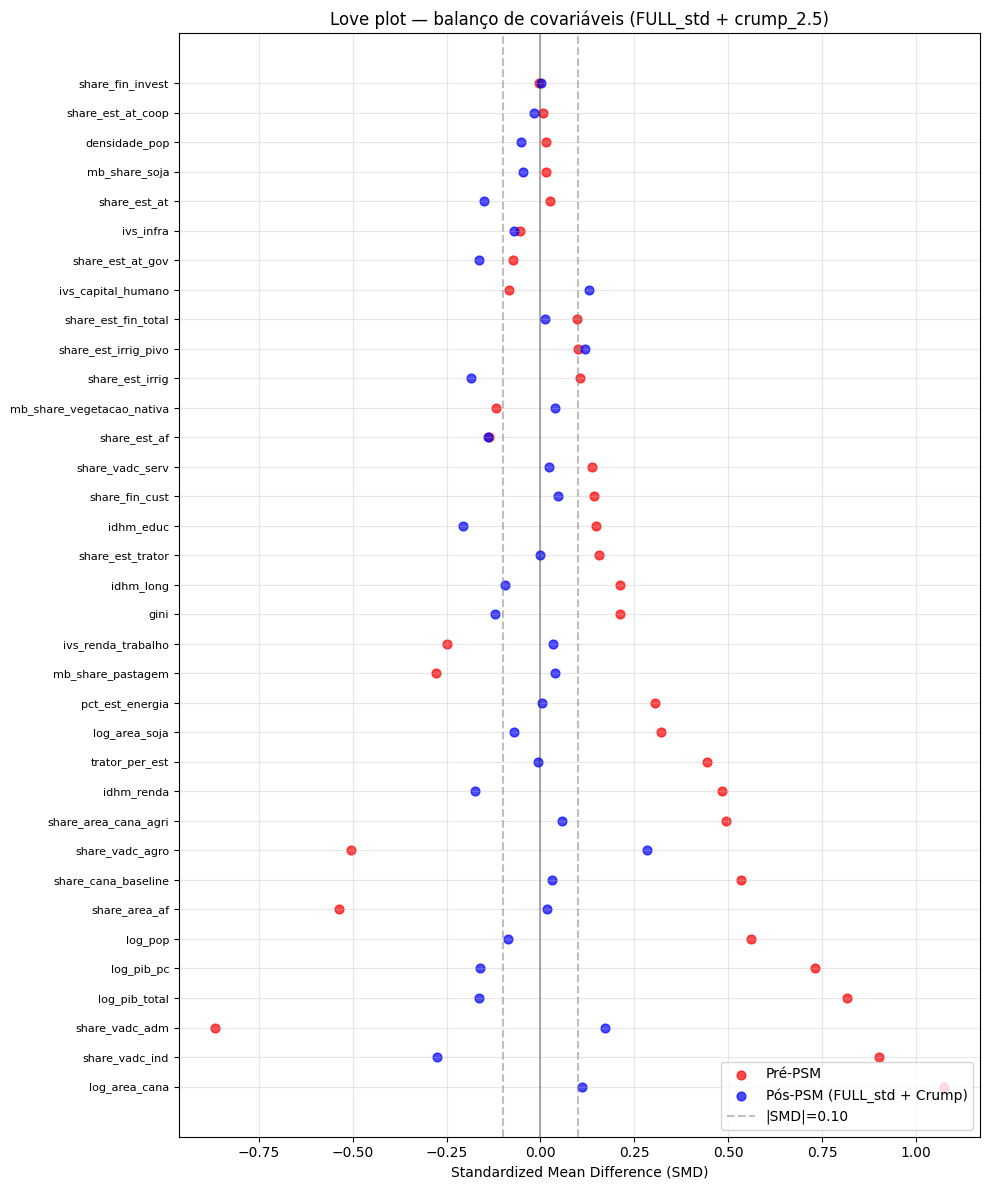

In [13]:
# Love plot
fig, ax = plt.subplots(figsize=(10, 12))
y_pos = np.arange(len(balance_df))
ax.scatter(balance_df['SMD_pre'],  y_pos, label='Pré-PSM', color='red', alpha=0.7, s=40)
ax.scatter(balance_df['SMD_post'], y_pos, label='Pós-PSM (FULL_std + Crump)', color='blue', alpha=0.7, s=40)
ax.axvline(x=0,    color='black', linestyle='-',  alpha=0.3)
ax.axvline(x=0.10, color='gray',  linestyle='--', alpha=0.5, label='|SMD|=0.10')
ax.axvline(x=-0.10,color='gray',  linestyle='--', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(balance_df['covariavel'], fontsize=8)
ax.set_xlabel('Standardized Mean Difference (SMD)')
ax.set_title(f'Love plot — balanço de covariáveis ({principal_key} + {principal_method})')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bloco 10 — Distribuição de pscores por grupo (sanity check)

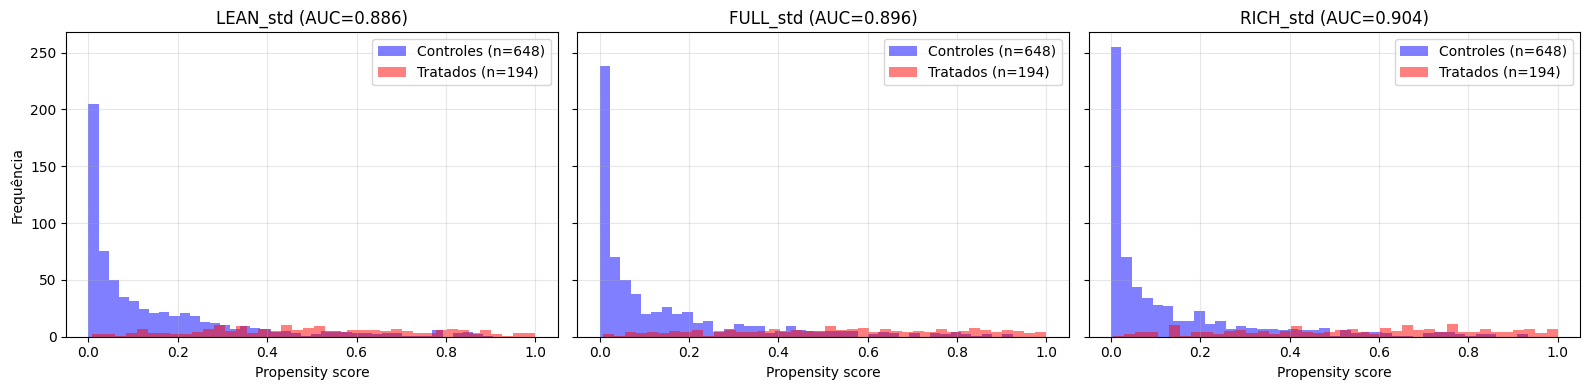

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, spec_name in zip(axes, ['LEAN', 'FULL', 'RICH']):
    p = results[f'{spec_name}_std']['pscore']
    ax.hist(p[y==0], bins=40, alpha=0.5, label='Controles (n=648)', color='blue')
    ax.hist(p[y==1], bins=40, alpha=0.5, label='Tratados (n=194)', color='red')
    ax.set_xlabel('Propensity score')
    ax.set_title(f'{spec_name}_std (AUC={results[f"{spec_name}_std"]["auc"]:.3f})')
    ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Frequência')
plt.tight_layout()
plt.show()

## Bloco 11 — Salvar artefatos

In [15]:
out_psm = BASE_DIR / 'data/interim'
out_psm.mkdir(parents=True, exist_ok=True)

# 1. pscores e weights
weights_df.to_csv(out_psm / 'psm_pscores_weights.csv', index=False)
print(f'✓ psm_pscores_weights.csv ({weights_df.shape})')

# 2. Support masks
support_masks_df = pd.DataFrame({'geocode': df_psm['geocode'].values, 'treated': y})
for (model, method), mask in support_masks.items():
    support_masks_df[f'in_{model}_{method}'] = mask.astype(int)
support_masks_df.to_csv(out_psm / 'psm_support_masks.csv', index=False)
print(f'✓ psm_support_masks.csv ({support_masks_df.shape})')

# 3. Diagnóstico (modelos)
diag_df = pd.DataFrame([
    {
        'model': k,
        'auc': r['auc'],
        'pseudo_r2': r['pseudo_r2'],
        'n_covs_total': len(r['covs']),
        'n_active': r['n_active'],
        'active_covs': '; '.join(r['active_covs']),
    }
    for k, r in results.items()
])
diag_df.to_csv(out_psm / 'psm_diagnostics.csv', index=False)
print(f'✓ psm_diagnostics.csv ({diag_df.shape})')

# 4. Suporte comum (tabela 6×4)
support_df.to_csv(out_psm / 'psm_support_summary.csv', index=False)
print(f'✓ psm_support_summary.csv ({support_df.shape})')

# 5. Balanço SMDs
balance_df.to_csv(out_psm / 'psm_balance_smd.csv', index=False)
print(f'✓ psm_balance_smd.csv ({balance_df.shape})')

print('\n✓ Todos os artefatos salvos em data/interim/')

✓ psm_pscores_weights.csv ((842, 26))
✓ psm_support_masks.csv ((842, 34))
✓ psm_diagnostics.csv ((8, 6))
✓ psm_support_summary.csv ((32, 9))
✓ psm_balance_smd.csv ((35, 5))

✓ Todos os artefatos salvos em data/interim/


## Resumo final

Se o notebook rodou com sucesso:

1. **6 modelos PSM estimados** (LEAN/FULL/RICH × {std, lasso}) sobre 842 munis canavieiros
2. **4 critérios de suporte aplicados** em cada modelo (= 24 amostras analíticas)
3. **Pesos ATT-IPW** salvos para cada modelo (uso em CS doubly-robust)
4. **Balanço SMD** verificado para o modelo principal (FULL_std + Crump)
5. **Tabela comparativa TCC × v2.3** documenta queda esperada de AUC sob universo canavieiro

**Próxima fase B4 — robustezes principais (4 testes da §8 v2.3.3):**
- §8.1 placebo temporal
- §8.2 vizinho tratado (SUTVA)
- §8.3 janela alternativa 2012-2024
- §8.4 *near-2×2* (TWFE restrito a g=2020 ∪ never-treated)

**Decisão do estimador principal CS:** os pscores e weights aqui estimados serão consumidos pelo módulo `differences` (Python) na construção do estimador Callaway-Sant'Anna doubly-robust com `share_cana_baseline` no IPW (conforme §3.7.1 v2.3.3).

**TODO operacional:**
- Investigar 10 municípios extremos (positivity violation persistente sob qualquer spec) — caracterização individual em apêndice (§3.6.1 + Apêndice C synthetic control).

In [16]:
# ============================================================
# TABLE 2 — Descriptive statistics + SMD balance diagnostics
# Principal FULL2 specification
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 0. Principal specification
# ------------------------------------------------------------
principal_key = "FULL2_std"
principal_method = "crump_2.5"
covs_table2 = COVS_FULL2.copy()

assert principal_key in results, f"{principal_key} não encontrado em results."
assert (principal_key, principal_method) in support_masks, (
    f"Máscara de suporte {(principal_key, principal_method)} não encontrada."
)

support_mask = support_masks[(principal_key, principal_method)]
p = results[principal_key]["pscore"]
y = df_psm["treated"].astype(int).values

# ATT weights: treated = 1; controls = p/(1-p)
w_att = np.where(y == 1, 1.0, p / (1 - p))

# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def mean_sd(x, w=None):
    """Return mean and SD; weighted if w is provided."""
    x = np.asarray(x, dtype=float)

    if w is None:
        m = np.nanmean(x)
        sd = np.nanstd(x, ddof=1)
        return m, sd

    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w) & (w > 0)

    x = x[mask]
    w = w[mask]

    if len(x) == 0:
        return np.nan, np.nan

    m = np.average(x, weights=w)
    v = np.average((x - m) ** 2, weights=w)
    sd = np.sqrt(v)
    return m, sd


def smd_unweighted(x, treated):
    """Unweighted standardized mean difference."""
    x = np.asarray(x, dtype=float)
    treated = np.asarray(treated).astype(bool)

    mt, sdt = mean_sd(x[treated])
    mc, sdc = mean_sd(x[~treated])

    pooled = np.sqrt((sdt**2 + sdc**2) / 2)
    if pooled == 0 or np.isnan(pooled):
        return 0.0

    return (mt - mc) / pooled


def smd_weighted(x, treated, support, weights):
    """Weighted SMD in the common-support sample."""
    x = np.asarray(x, dtype=float)
    treated = np.asarray(treated).astype(bool)
    support = np.asarray(support).astype(bool)
    weights = np.asarray(weights, dtype=float)

    mt, sdt = mean_sd(x[support & treated], weights[support & treated])
    mc, sdc = mean_sd(x[support & ~treated], weights[support & ~treated])

    pooled = np.sqrt((sdt**2 + sdc**2) / 2)
    if pooled == 0 or np.isnan(pooled):
        return 0.0

    return (mt - mc) / pooled


def fmt_num(x, digits=3):
    if pd.isna(x):
        return ""
    return f"{x:.{digits}f}"


def latex_escape(s):
    return (
        str(s)
        .replace("\\", "\\textbackslash{}")
        .replace("_", "\\_")
        .replace("%", "\\%")
        .replace("&", "\\&")
    )


# ------------------------------------------------------------
# 2. Variable labels and dimensions
# ------------------------------------------------------------
var_labels = {
    "log_pib_total": "Total GDP (log)",
    "log_pib_pc": "GDP per capita (log)",
    "log_pop": "Population (log)",
    "densidade_pop": "Population density",
    "share_vadc_serv": "Services VA share",
    "share_vadc_adm": "Public administration VA share",

    "share_cana_baseline": "Sugarcane share (MapBiomas)",
    "mb_share_soja": "Soybean share (MapBiomas)",
    "mb_share_pastagem": "Pasture share (MapBiomas)",
    "mb_share_vegetacao_nativa": "Native vegetation share",

    "log_area_cana": "Sugarcane area (log)",
    "log_area_soja": "Soybean area (log)",
    "share_area_cana_agri": "Sugarcane share of crop area",

    "share_est_af": "Family farms share",
    "share_area_af": "Family-farm area share",

    "trator_per_est": "Tractors per farm",
    "share_est_irrig": "Irrigated farms share",
    "share_est_fin_total": "Financed farms share",

    "ivs_infra": "IVS infrastructure",
    "gini": "Gini index",

    "idhm_educ": "HDI education",
    "idhm_renda": "HDI income",
    "idhm_long": "HDI longevity",
    "ivs_capital_humano": "IVS human capital",
    "ivs_renda_trabalho": "IVS income and work",

    "share_est_at": "Technical assistance share",
    "share_est_at_coop": "Cooperative technical assistance",
    "share_est_at_gov": "Government technical assistance",

    "share_fin_invest": "Investment credit share",
    "share_fin_cust": "Working-capital credit share",

    "share_est_trator": "Farms with tractors share",
    "share_est_irrig_pivo": "Center-pivot irrigation share",
    "pct_est_energia": "Farms with electricity share",
}

dimension_map = {
    "Economic and demographic structure": [
        "log_pib_total", "log_pib_pc", "log_pop", "densidade_pop",
        "share_vadc_serv", "share_vadc_adm",
    ],
    "Baseline land use": [
        "share_cana_baseline", "mb_share_soja", "mb_share_pastagem",
        "mb_share_vegetacao_nativa",
    ],
    "Crop scale and specialization": [
        "log_area_cana", "log_area_soja", "share_area_cana_agri",
    ],
    "Agrarian structure": [
        "share_est_af", "share_area_af",
    ],
    "Technology, credit, and infrastructure": [
        "trator_per_est", "share_est_irrig", "share_est_fin_total",
        "share_est_at", "share_est_at_coop", "share_est_at_gov",
        "share_fin_invest", "share_fin_cust", "share_est_trator",
        "share_est_irrig_pivo", "pct_est_energia",
    ],
    "Socioeconomic vulnerability": [
        "ivs_infra", "gini", "idhm_educ", "idhm_renda", "idhm_long",
        "ivs_capital_humano", "ivs_renda_trabalho",
    ],
}

var_to_dimension = {}
for dim, cols in dimension_map.items():
    for c in cols:
        var_to_dimension[c] = dim

# keep only variables that are actually in FULL2
dimension_order = []
for dim, cols in dimension_map.items():
    kept = [c for c in cols if c in covs_table2]
    if kept:
        dimension_order.append((dim, kept))

# sanity check
missing_labels = [c for c in covs_table2 if c not in var_labels]
if missing_labels:
    print("⚠️ Variáveis sem label customizado:", missing_labels)


# ------------------------------------------------------------
# 3. Build descriptive + balance table
# ------------------------------------------------------------
rows = []

for c in covs_table2:
    x = df_psm[c].astype(float).values

    # pre-trim, unweighted treated/control descriptive stats
    mt_pre, sdt_pre = mean_sd(x[y == 1])
    mc_pre, sdc_pre = mean_sd(x[y == 0])

    smd_pre = smd_unweighted(x, y == 1)
    smd_post = smd_weighted(x, y == 1, support_mask, w_att)

    # optional post-support weighted means, useful for appendix/diagnostics
    mt_post, sdt_post = mean_sd(
        x[(support_mask) & (y == 1)],
        w_att[(support_mask) & (y == 1)]
    )
    mc_post, sdc_post = mean_sd(
        x[(support_mask) & (y == 0)],
        w_att[(support_mask) & (y == 0)]
    )

    rows.append({
        "dimension": var_to_dimension.get(c, "Other"),
        "covariate": c,
        "label": var_labels.get(c, c),
        "mean_treated": mt_pre,
        "sd_treated": sdt_pre,
        "mean_control": mc_pre,
        "sd_control": sdc_pre,
        "SMD_pre": smd_pre,
        "abs_SMD_pre": abs(smd_pre),
        "SMD_post": smd_post,
        "abs_SMD_post": abs(smd_post),
        "mean_treated_post": mt_post,
        "sd_treated_post": sdt_post,
        "mean_control_post_weighted": mc_post,
        "sd_control_post_weighted": sdc_post,
    })

table2_df = pd.DataFrame(rows)

# order by predefined dimensions and covariate order
order_index = {c: i for i, c in enumerate(covs_table2)}
table2_df["order"] = table2_df["covariate"].map(order_index)
table2_df = table2_df.sort_values("order").drop(columns="order")

# counts
n_treated_pre = int((y == 1).sum())
n_control_pre = int((y == 0).sum())
n_total_pre = len(y)

n_treated_post = int(((y == 1) & support_mask).sum())
n_control_post = int(((y == 0) & support_mask).sum())
n_total_post = int(support_mask.sum())

print("Table 2 sample accounting")
print(f"Pre-trim:  n = {n_total_pre} | treated = {n_treated_pre} | controls = {n_control_pre}")
print(f"Post-trim: n = {n_total_post} | treated = {n_treated_post} | controls = {n_control_post}")
print(f"Coverage treated: {100*n_treated_post/n_treated_pre:.1f}%")
print(f"Coverage controls: {100*n_control_post/n_control_pre:.1f}%")

print("\nBalance summary")
print(f"Mean |SMD| pre:  {table2_df['abs_SMD_pre'].mean():.3f}")
print(f"Mean |SMD| post: {table2_df['abs_SMD_post'].mean():.3f}")
print(f"Max |SMD| pre:   {table2_df['abs_SMD_pre'].max():.3f}")
print(f"Max |SMD| post:  {table2_df['abs_SMD_post'].max():.3f}")
print(f"Covariates with |SMD| post < 0.10: {(table2_df['abs_SMD_post'] < 0.10).sum()} / {len(table2_df)}")
print(f"Covariates with |SMD| post < 0.25: {(table2_df['abs_SMD_post'] < 0.25).sum()} / {len(table2_df)}")

display_cols = [
    "dimension", "label", "mean_treated", "sd_treated",
    "mean_control", "sd_control", "abs_SMD_pre", "abs_SMD_post"
]
display(table2_df[display_cols])


# ------------------------------------------------------------
# 4. Export CSV
# ------------------------------------------------------------
out_psm = BASE_DIR / "data/interim"
out_psm.mkdir(parents=True, exist_ok=True)

csv_path = out_psm / "table2_descriptives_smd_FULL2.csv"
table2_df.to_csv(csv_path, index=False)
print(f"\n✓ CSV exported: {csv_path}")


# ------------------------------------------------------------
# 5. Export LaTeX table
# ------------------------------------------------------------
latex_lines = []

latex_lines.append(r"%% =========================================================")
latex_lines.append(r"%% TABLE 2 — Descriptives + SMD")
latex_lines.append(r"%% Generated from 10_psm_baseline_v2.ipynb")
latex_lines.append(r"%% =========================================================")
latex_lines.append(r"\begin{table*}[t]")
latex_lines.append(r"\centering")
latex_lines.append(
    r"\caption{Descriptive statistics and balance diagnostics for the "
    r"33 covariates entering the principal FULL2 propensity-score "
    r"specification. Means and standard deviations are reported for "
    r"treated and never-treated municipalities before common-support "
    r"trimming. Standardized mean differences (SMDs) are reported before "
    r"trimming and after Crump trimming with ATT weights in the "
    r"common-support sample.}"
)
latex_lines.append(r"\label{tab:descriptives}")
latex_lines.append(r"\scriptsize")
latex_lines.append(r"\setlength{\tabcolsep}{3.2pt}")
latex_lines.append(r"\renewcommand{\arraystretch}{1.08}")
latex_lines.append(r"\begin{tabular}{@{}lrrrrrr@{}}")
latex_lines.append(r"\toprule")
latex_lines.append(
    r"Covariate & "
    r"\multicolumn{2}{c}{Treated} & "
    r"\multicolumn{2}{c}{Never-treated} & "
    r"\multicolumn{2}{c}{Balance} \\"
)
latex_lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(l){6-7}")
latex_lines.append(
    r"& Mean & SD & Mean & SD & $|\mathrm{SMD}|$ pre & $|\mathrm{SMD}|$ post \\"
)
latex_lines.append(r"\midrule")

for dim, cols in dimension_order:
    latex_lines.append(
        rf"\multicolumn{{7}}{{@{{}}l}}{{\textit{{{latex_escape(dim)}}}}} \\"
    )

    sub = table2_df[table2_df["covariate"].isin(cols)].copy()
    sub["ord"] = sub["covariate"].map(order_index)
    sub = sub.sort_values("ord")

    for _, r in sub.iterrows():
        latex_lines.append(
            f"{latex_escape(r['label'])} & "
            f"{fmt_num(r['mean_treated'])} & "
            f"{fmt_num(r['sd_treated'])} & "
            f"{fmt_num(r['mean_control'])} & "
            f"{fmt_num(r['sd_control'])} & "
            f"{fmt_num(r['abs_SMD_pre'])} & "
            f"{fmt_num(r['abs_SMD_post'])} \\\\"
        )

    latex_lines.append(r"\addlinespace[0.25em]")

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\vspace{0.6ex}")
latex_lines.append(r"\begin{minipage}{0.98\textwidth}")
latex_lines.append(r"\footnotesize")
latex_lines.append(
    rf"\textit{{Notes:}} The pre-trim sample contains "
    rf"$n={n_total_pre}$ municipalities ($n_1={n_treated_pre}$ treated and "
    rf"$n_0={n_control_pre}$ never-treated). The common-support sample under "
    rf"the principal FULL2 specification and Crump trimming contains "
    rf"$n={n_total_post}$ municipalities ($n_1={n_treated_post}$ treated and "
    rf"$n_0={n_control_post}$ never-treated). "
    r"All variables are reported in the transformed units used in the "
    r"propensity-score model. Post-trimming SMDs are computed with ATT weights."
)
latex_lines.append(r"\end{minipage}")
latex_lines.append(r"\end{table*}")

latex_text = "\n".join(latex_lines)

tex_path = out_psm / "table2_descriptives_smd_FULL2.tex"
tex_path.write_text(latex_text, encoding="utf-8")

print(f"✓ LaTeX exported: {tex_path}")
print("\nPreview of LaTeX first lines:\n")
print("\n".join(latex_lines[:25]))

Table 2 sample accounting
Pre-trim:  n = 842 | treated = 194 | controls = 648
Post-trim: n = 820 | treated = 189 | controls = 631
Coverage treated: 97.4%
Coverage controls: 97.4%

Balance summary
Mean |SMD| pre:  0.288
Mean |SMD| post: 0.042
Max |SMD| pre:   1.073
Max |SMD| post:  0.123
Covariates with |SMD| post < 0.10: 32 / 33
Covariates with |SMD| post < 0.25: 33 / 33


,dimension,label,mean_treated,sd_treated,mean_control,sd_control,abs_SMD_pre,abs_SMD_post
0,Economic and demographic structure,Total GDP (log),13.536304,0.977903,12.558550,1.387262,0.814684,0.074281
1,Economic and demographic structure,GDP per capita (log),10.502069,0.462505,10.143749,0.518800,0.729095,0.010731
2,Economic and demographic structure,Population (log),9.942094,1.012088,9.322746,1.196413,0.558933,0.071627
3,Economic and demographic structure,Population density,81.810862,122.109170,79.664518,184.203320,0.013735,0.044786
4,Economic and demographic structure,Services VA share,0.398779,0.130047,0.380830,0.129654,0.138228,0.062288
5,Baseline land use,Sugarcane share (MapBiomas),0.302268,0.213837,0.194344,0.191063,0.532248,0.026265
6,Baseline land use,Soybean share (MapBiomas),0.087990,0.130688,0.086019,0.137864,0.014675,0.055481
7,Baseline land use,Pasture share (MapBiomas),0.216237,0.181507,0.268457,0.194974,0.277232,0.034195
8,Baseline land use,Native vegetation share,0.145000,0.098729,0.159059,0.137265,0.117587,0.003293
9,Crop scale and specialization,Sugarcane area (log),9.625933,0.906307,8.049272,1.870434,1.072793,0.038805



✓ CSV exported: /content/drive/MyDrive/Renovabio - EcoEco/data/interim/table2_descriptives_smd_FULL2.csv
✓ LaTeX exported: /content/drive/MyDrive/Renovabio - EcoEco/data/interim/table2_descriptives_smd_FULL2.tex

Preview of LaTeX first lines:

%% =========================================================
%% TABLE 2 — Descriptives + SMD
%% Generated from 10_psm_baseline_v2.ipynb
%% =========================================================
\begin{table*}[t]
\centering
\caption{Descriptive statistics and balance diagnostics for the 33 covariates entering the principal FULL2 propensity-score specification. Means and standard deviations are reported for treated and never-treated municipalities before common-support trimming. Standardized mean differences (SMDs) are reported before trimming and after Crump trimming with ATT weights in the common-support sample.}
\label{tab:descriptives}
\scriptsize
\setlength{\tabcolsep}{3.2pt}
\renewcommand{\arraystretch}{1.08}
\begin{tabular}{@{}lrrrrrr@{}